In [109]:
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt

pos = np.load('pos.npz')['pos']

fig = go.Figure(data=[
    go.Scatter3d(
        x=pos[:, 0],
        y=pos[:, 1],
        z=pos[:, 2],
        mode='markers',
        marker=dict(size=5, color='steelblue', opacity=1.0),
    )
])

fig.update_layout(
    scene=dict(
        xaxis=dict(range=[-1.2, 1.2]),
        yaxis=dict(range=[-1.2, 1.2]),
        zaxis=dict(range=[-1.2, 1.2]),
        aspectmode='cube',
    ),
)

fig.show()

In [110]:
def hist(val, bins=None, log=False):
    val = np.asarray(val)
    if bins is None:
        n = int(np.sqrt(len(val)))
        if log:
            bins = np.logspace(
                min(np.log10(val[val > 0])),
                max(np.log10(val[val > 0])),
                n
            )
        else:
            bins = np.linspace(
                min(val),
                max(val),
                n
            )
    p_val, edges = np.histogram(
        val,
        bins,
        density=True
    )
    return p_val, (edges[1:] + edges[:-1]) / 2

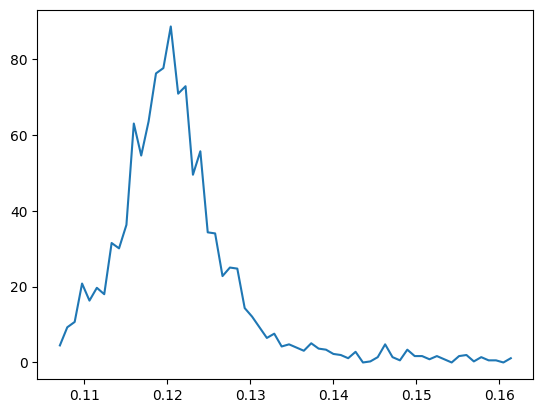

In [113]:
from scipy.spatial import ConvexHull

hull = ConvexHull(pos)

# review the euler formula

hull.simplices  # n_facets, n_dims
hull.points[hull.simplices]  # n_facets, n_points_in_facet, n_dims
np.diff(hull.points[hull.simplices], axis=1)  # n_facets, n_edges_in_facet, n_dims

edge_lengths = np.linalg.norm(np.diff(hull.points[hull.simplices], axis=1), axis=-1).flatten()

p_e, e = hist(edge_lengths)
plt.plot(e, p_e)